In [1]:
# for adage models
from adage import Adage as ad
from adage import SeqAdage

# for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# misc
#from scipy.stats import hypergeom
#import csv
#import random
import time
import tensorflow as tf

2026-07-28 10:48:48.259237: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-28 10:48:55.258096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785250138.630167 3047200 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785250139.724837 3047200 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785250146.421840 3047200 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import tensorflow as tf

print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
True


2026-07-28 10:50:47.462845: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4272 7923


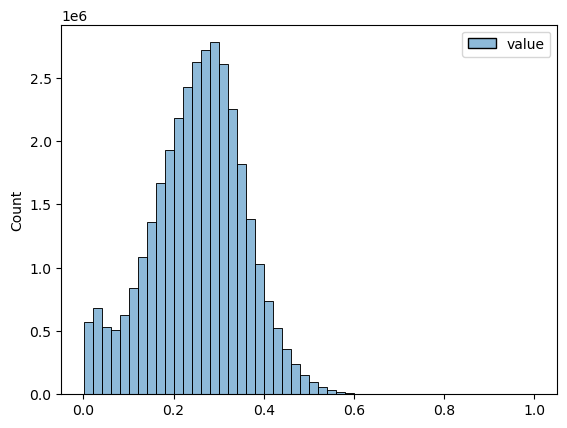

In [3]:
#adage_comp = pandas.read_csv('data_files/ADAGE_compendium.csv')
all_comp = pd.read_csv('../data_files/ecmg_mgsp_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(pd.melt(all_comp), bins = 50)

## Base features (from ADAGE)

For the sake of this efficiency, starting with the following parameters:

* hidden features: 300
* epochs: 500
* curruption: 0.01
* batchs zie: 10
* validatoin split: 0.1
* activation: sigmoid
* objective: binary cross-entropy



4272 4547


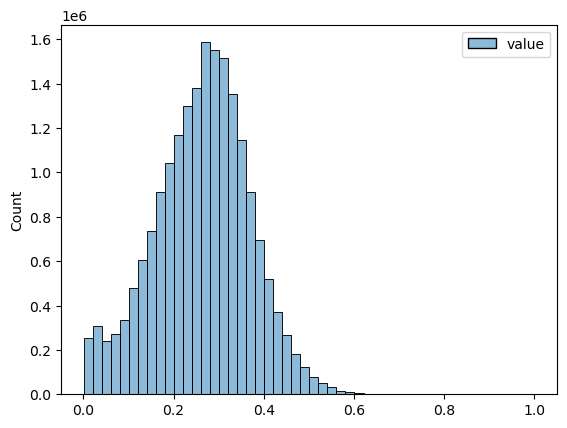

In [3]:
#adage_comp = pandas.read_csv('data_files/ADAGE_compendium.csv')
all_comp = pd.read_csv('../data_files/ecmg_mgs_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(pd.melt(all_comp), bins = 50)

In [8]:
all_comp.head()

,ERX484642,ERX484643,ERX484646,ERX484647,ERX546858,ERX546859,ERX546860,ERX530520,ERX530521,ERX530522,...,SRX28568279,SRX28568280,SRX28568281,SRX28568282,SRX28568283,SRX28568284,SRX28568285,SRX28568286,SRX28568287,SRX28568288
11997cc26382b2c286cd502685a104a5_100,0.281017,0.226761,0.129785,0.241405,0.261637,0.114690,0.235393,0.240089,0.233147,0.235058,...,0.234969,0.252177,0.260698,0.247420,0.246883,0.234117,0.246970,0.255041,0.257472,0.283609
11997cc26382b2c286cd502685a104a5_1000,0.346599,0.358053,0.353506,0.338200,0.374616,0.466359,0.369279,0.355487,0.363123,0.362282,...,0.374685,0.373322,0.372822,0.369746,0.374277,0.408697,0.407013,0.408400,0.410113,0.379170
11997cc26382b2c286cd502685a104a5_1002,0.373058,0.297600,0.295413,0.306084,0.314024,0.345913,0.290830,0.377934,0.363239,0.364106,...,0.267843,0.281960,0.270277,0.286839,0.285462,0.310358,0.301648,0.303480,0.302123,0.280250
11997cc26382b2c286cd502685a104a5_1004,0.275660,0.319125,0.300929,0.322015,0.295018,0.114690,0.284516,0.334188,0.316676,0.319073,...,0.342873,0.343209,0.339325,0.371996,0.367165,0.380688,0.383967,0.384157,0.387193,0.353062
11997cc26382b2c286cd502685a104a5_1006,0.141282,0.165153,0.129785,0.188975,0.241747,0.114690,0.188030,0.247172,0.238051,0.237825,...,0.192027,0.199502,0.188716,0.212084,0.195771,0.189590,0.199753,0.202453,0.196626,0.204377


In [5]:
649 - 571


78

In [4]:
comps = ["ecmg_mgs_lcn01.csv","ecmg_mgsp_lcn01.csv"]


model_dict_post = {}

stime = time.time()
ltime = 0
c = 0



seeds = list(range(0,3))
#seeds = random.sample(range(10000), 10)

for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/' + comp,
                                                  seed=seed+571,
                                                  enc_dim = 450,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=15,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5) 
        mseq = sa.train_model()
        sa.save_weights('/work/gd134/sA_out',name)
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

ad_ecmg_mgs_lcn01.csv_2026_07_27_571
Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0243 - val_loss: 0.0125
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0122 - val_loss: 0.0124
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0121 - val_loss: 0.0123
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0120 - val_loss: 0.0123
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0119 - val_loss: 0.0121
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0118 - val_loss: 0.0121
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0117 - val_loss: 0.0120
Epoch 9/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0116 - val_loss: 0.0120
Epoch 10/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0115 - val_loss: 0.0119
Epoch 11/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0114 - val_loss: 0.0119
Epoc

In [8]:
print(rtime)
print(c)
print(ltime / c)
print(rtime / 60)

314.2315139770508
3
104.74331068992615
5.237191899617513


In [9]:
len(comps)

1

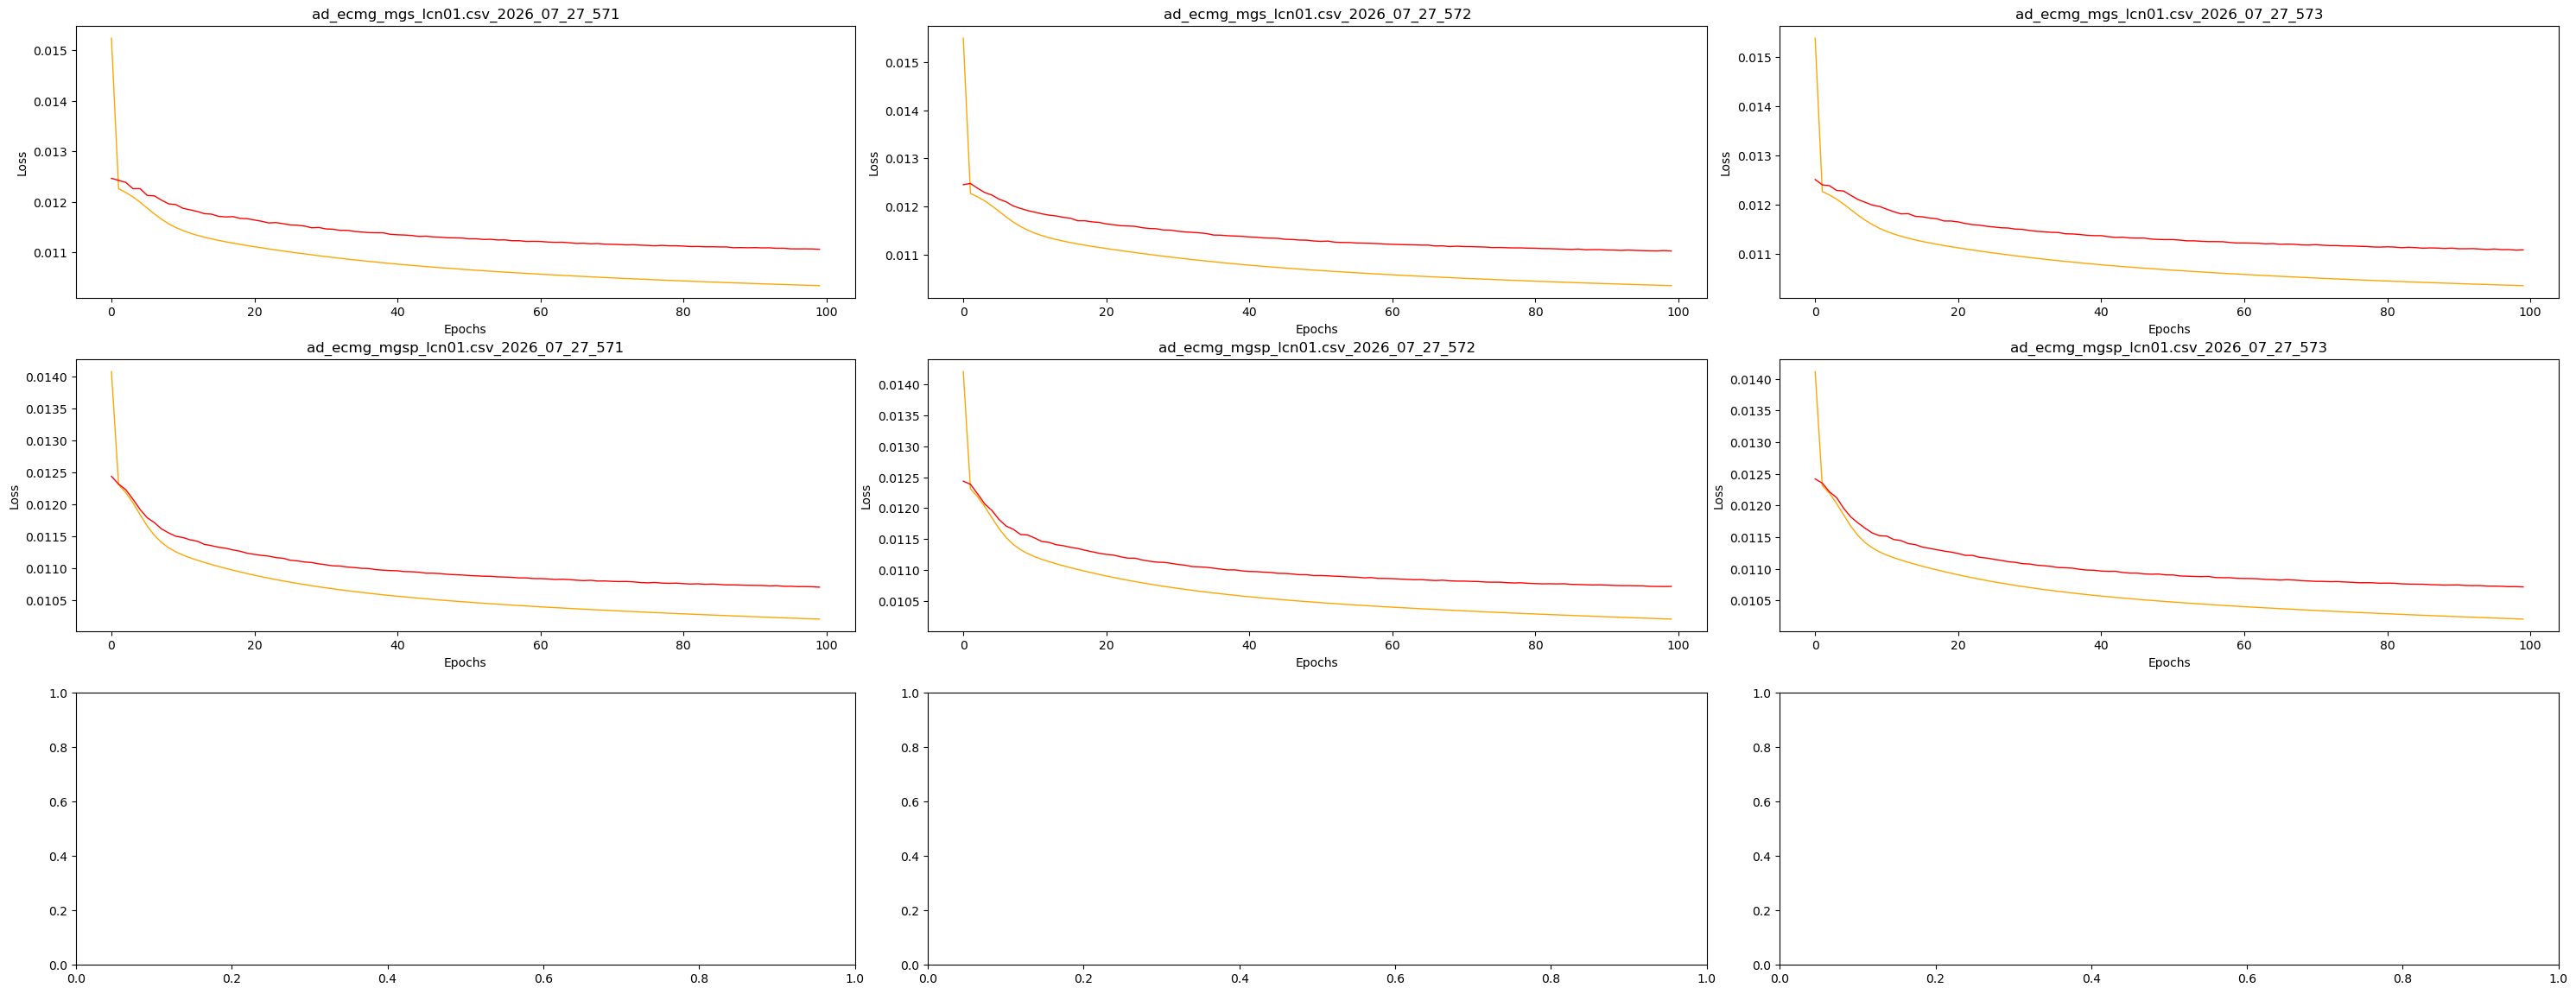

In [5]:

# set layout for panels of compendia and seeds
xd = len(comps) +1
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*10 ,yd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for comp in comps:
    xi=0
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1, 
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss, 
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1
    

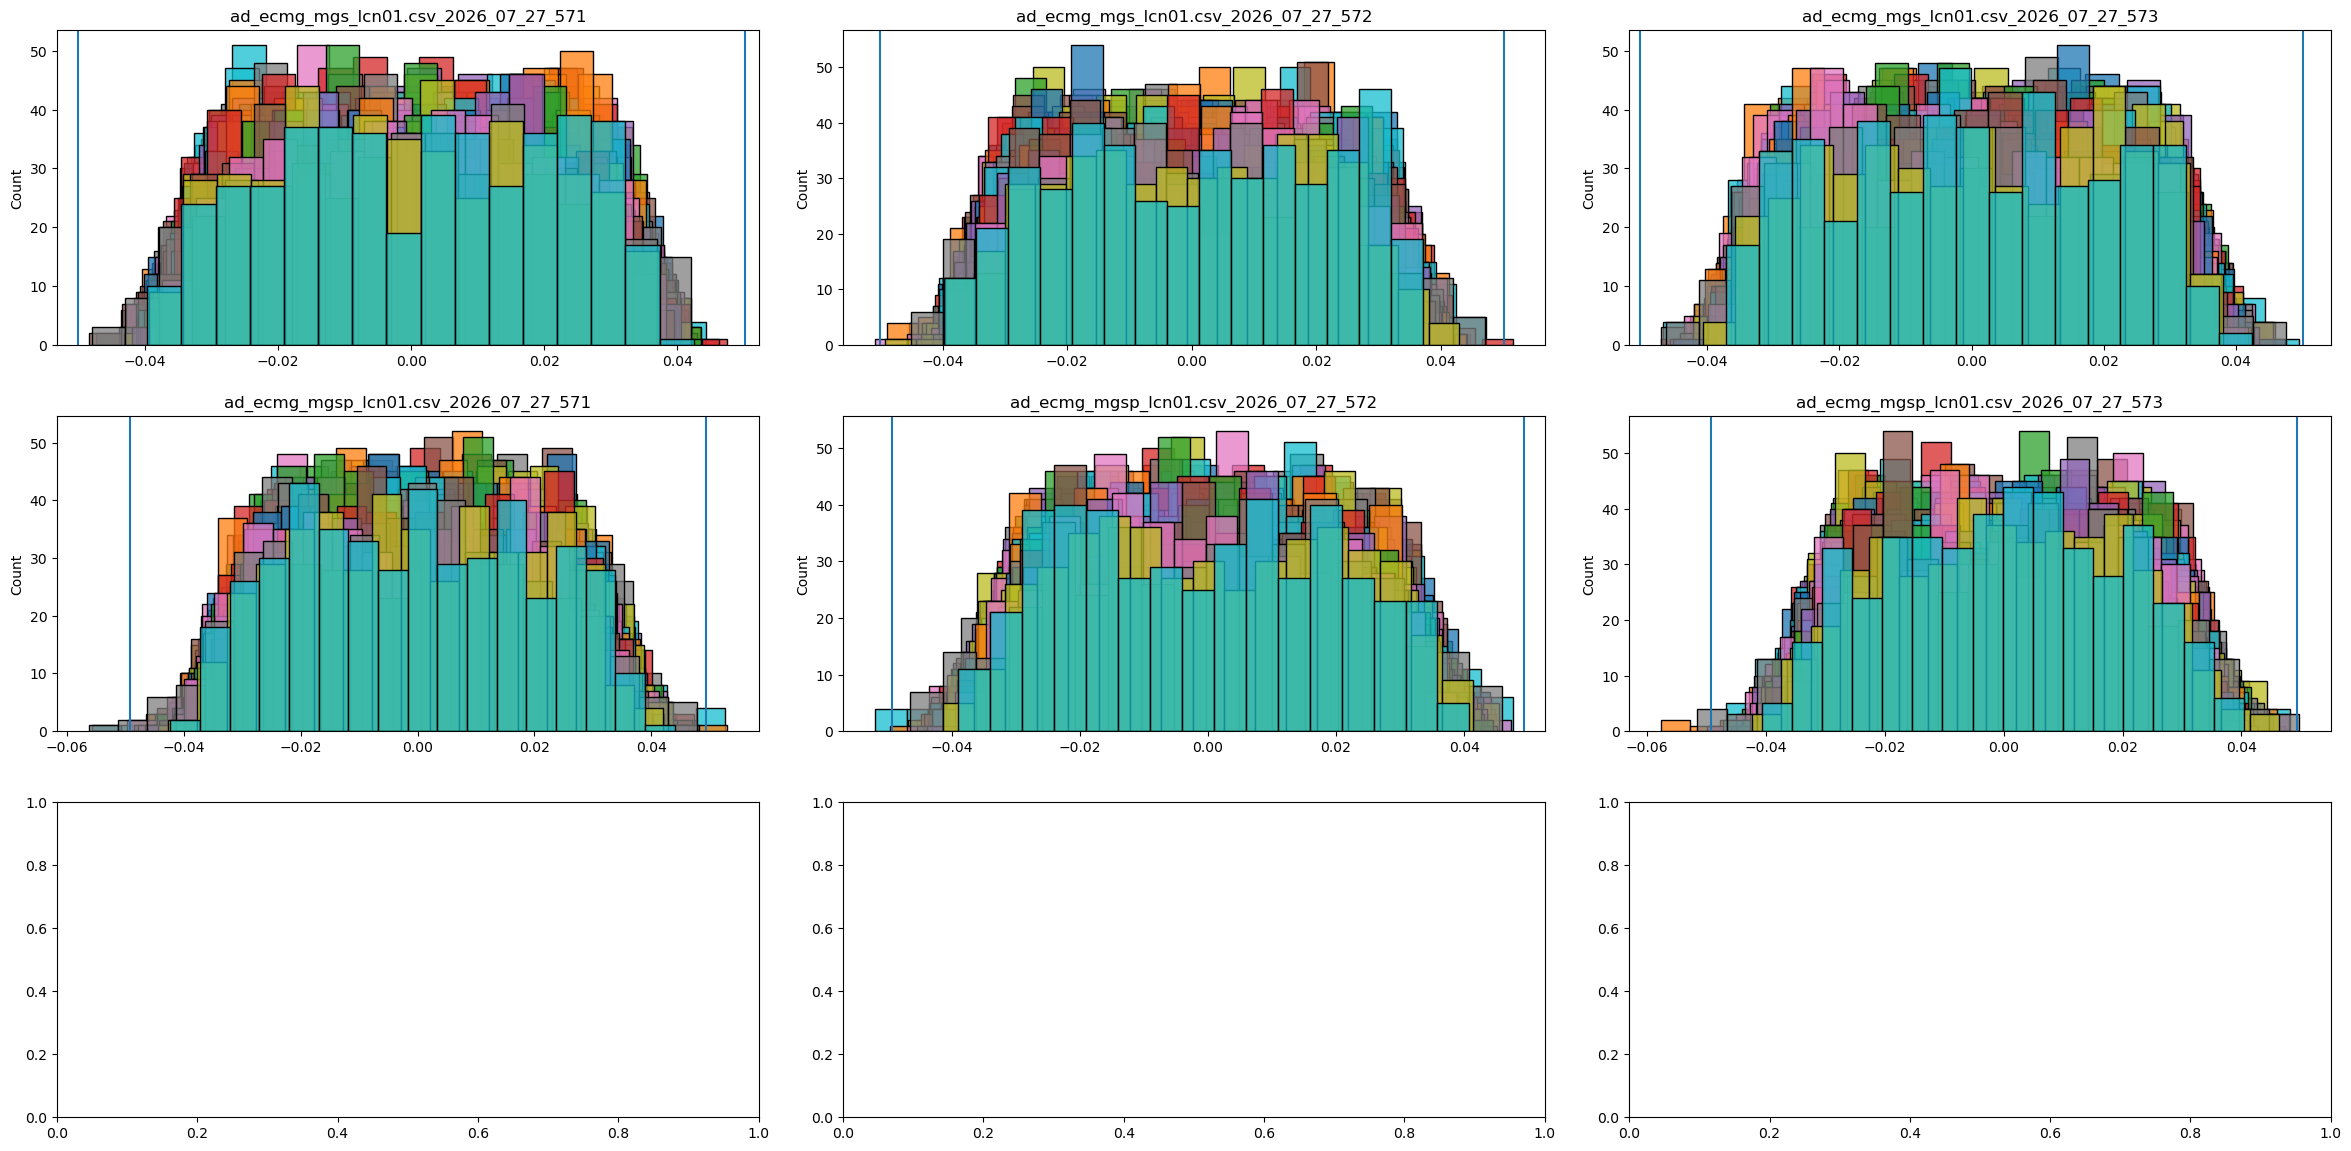

In [6]:
# set layout for panels of compendia and seeds
xd = len(comps) +1
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in comps:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node], 
                ax=ax[xi,yi],
                binwidth = 0.005, 
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1


In [7]:
# a dict to store the models
comps = ["ecmg_mgs_lcn01.csv","ecmg_mgsp_lcn01.csv"]
model_dict_tune = {}
model_dict_best = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/'+comp,
                                                  seed=seed+571) 
        mseq, t = sa.tune_model(seed+571,u=[50,500,25])
        #temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_tune[name] = t
        model_dict_best[name] = mseq
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

Trial 90 Complete [00h 00m 34s]
val_loss: 0.0040701101534068584

Best val_loss So Far: 0.003241834230720997
Total elapsed time: 00h 24m 38s
Results summary
Results in /work/gd134/hyperband_search_dir/ecmg_mgsp_lcn01_573
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0050 summary
Hyperparameters:
units: 50
dropout: 0.6000000000000001
act1: sigmoid
act2: celu
shuffle: True
init: glorot_normal
kl1: 0.02
kl2: 0.5
lr: 0.051000000000000004
bs: 5
mm: 0.4
tied: 0
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0046
Score: 0.003241834230720997

Trial 0046 summary
Hyperparameters:
units: 50
dropout: 0.6000000000000001
act1: sigmoid
act2: celu
shuffle: True
init: glorot_normal
kl1: 0.02
kl2: 0.5
lr: 0.051000000000000004
bs: 5
mm: 0.4
tied: 0
tuner/epochs: 17
tuner/initial_epoch: 6
tuner/bracket: 3
tuner/round: 2
tuner/trial_id: 0034
Score: 0.003713647136464715

Trial 0034 summary
Hyperparameters:
units: 50
dropout: 0.600000000000

In [14]:
HP_list = []

for t in list(model_dict_tune.keys()):
    sp = t[:-4]
    seed = t[-3:]
    trialsSE = model_dict_tune[t].oracle.get_best_trials(num_trials=20)
    i = 0
    for trial in trialsSE:
        HP_list.append(trial.hyperparameters.get_config()["values"] | 
                       {"Score": trial.score}| 
                       {"Trial ID": trial.trial_id} | 
                       {"Best step": trial.best_step} | 
                       {"tuner_key" : t} | 
                       {"species" : sp} | 
                       {"seed" : seed} | 
                       {"rank" : i})
        i+=1

tuners_df = pd.DataFrame(HP_list)

#tuners_df["tied_bool"] = tuners_df["tied"].astype("bool")

tuners_df.head(n=20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
units,175,50,50,50,50,50,100,100,125,125,125,175,175,175,175,175,175,175,275,275
dropout,0.8,0.0,0.1,0.0,0.1,0.0,0.4,0.4,0.8,0.8,0.8,0.8,0.8,0.4,0.7,0.8,0.7,0.4,0.4,0.0
act1,relu,relu,sigmoid,relu,sigmoid,relu,celu,celu,sigmoid,sigmoid,sigmoid,relu,relu,sigmoid,celu,relu,celu,sigmoid,celu,celu
act2,tanh,tanh,tanh,tanh,tanh,tanh,celu,celu,tanh,tanh,tanh,tanh,tanh,tanh,tanh,tanh,tanh,tanh,tanh,tanh
shuffle,True,True,True,True,True,True,True,True,False,False,False,True,True,True,False,True,False,True,True,True
init,glorot_normal,glorot_uniform,glorot_normal,glorot_uniform,glorot_normal,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,glorot_normal,glorot_normal,glorot_normal,glorot_uniform,glorot_normal,glorot_uniform,glorot_normal,glorot_uniform,glorot_normal
kl1,0.14,0.11,0.11,0.11,0.11,0.11,0.085,0.085,0.095,0.095,0.095,0.14,0.14,0.025,0.115,0.14,0.115,0.025,0.12,0.005
kl2,0.85,0.75,0.75,0.75,0.75,0.75,0.45,0.45,0.5,0.5,0.5,0.85,0.85,0.8,0.5,0.85,0.5,0.8,0.35,0.8
lr,0.031,0.011,0.031,0.011,0.031,0.011,0.091,0.091,0.041,0.041,0.041,0.031,0.031,0.051,0.061,0.031,0.061,0.051,0.071,0.081
bs,5,10,30,10,30,10,15,15,20,20,20,5,5,40,30,5,30,40,35,15


In [19]:
comps = ["ecmg_mgs_lcn01.csv"]


model_dict_post = {}

stime = time.time()
ltime = 0
c = 0



seeds = list(range(0,3))
#seeds = random.sample(range(10000), 10)

for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/ecmg_mgs_lcn01.csv',
                                                  seed=seed+571,
                                                  enc_dim = 175,
                                                  kl1=0.14,
                                                  kl2=0.85,
                                                  act = "relu",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=5,
                                                  dropout = .8,
                                                  mm = 0.7,
                                                  lr = 0.031) 
        mseq = sa.train_model()
        sa.save_weights('/work/gd134/sA_out',name)
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

ad_ecmg_mgs_lcn01.csv_2026_07_27_571
Epoch 1/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0511 - val_loss: 0.0125
Epoch 2/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoch 3/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0124 - val_loss: 0.0125
Epoch 4/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoch 5/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoch 6/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoch 7/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 8/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 9/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 10/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 11/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoc

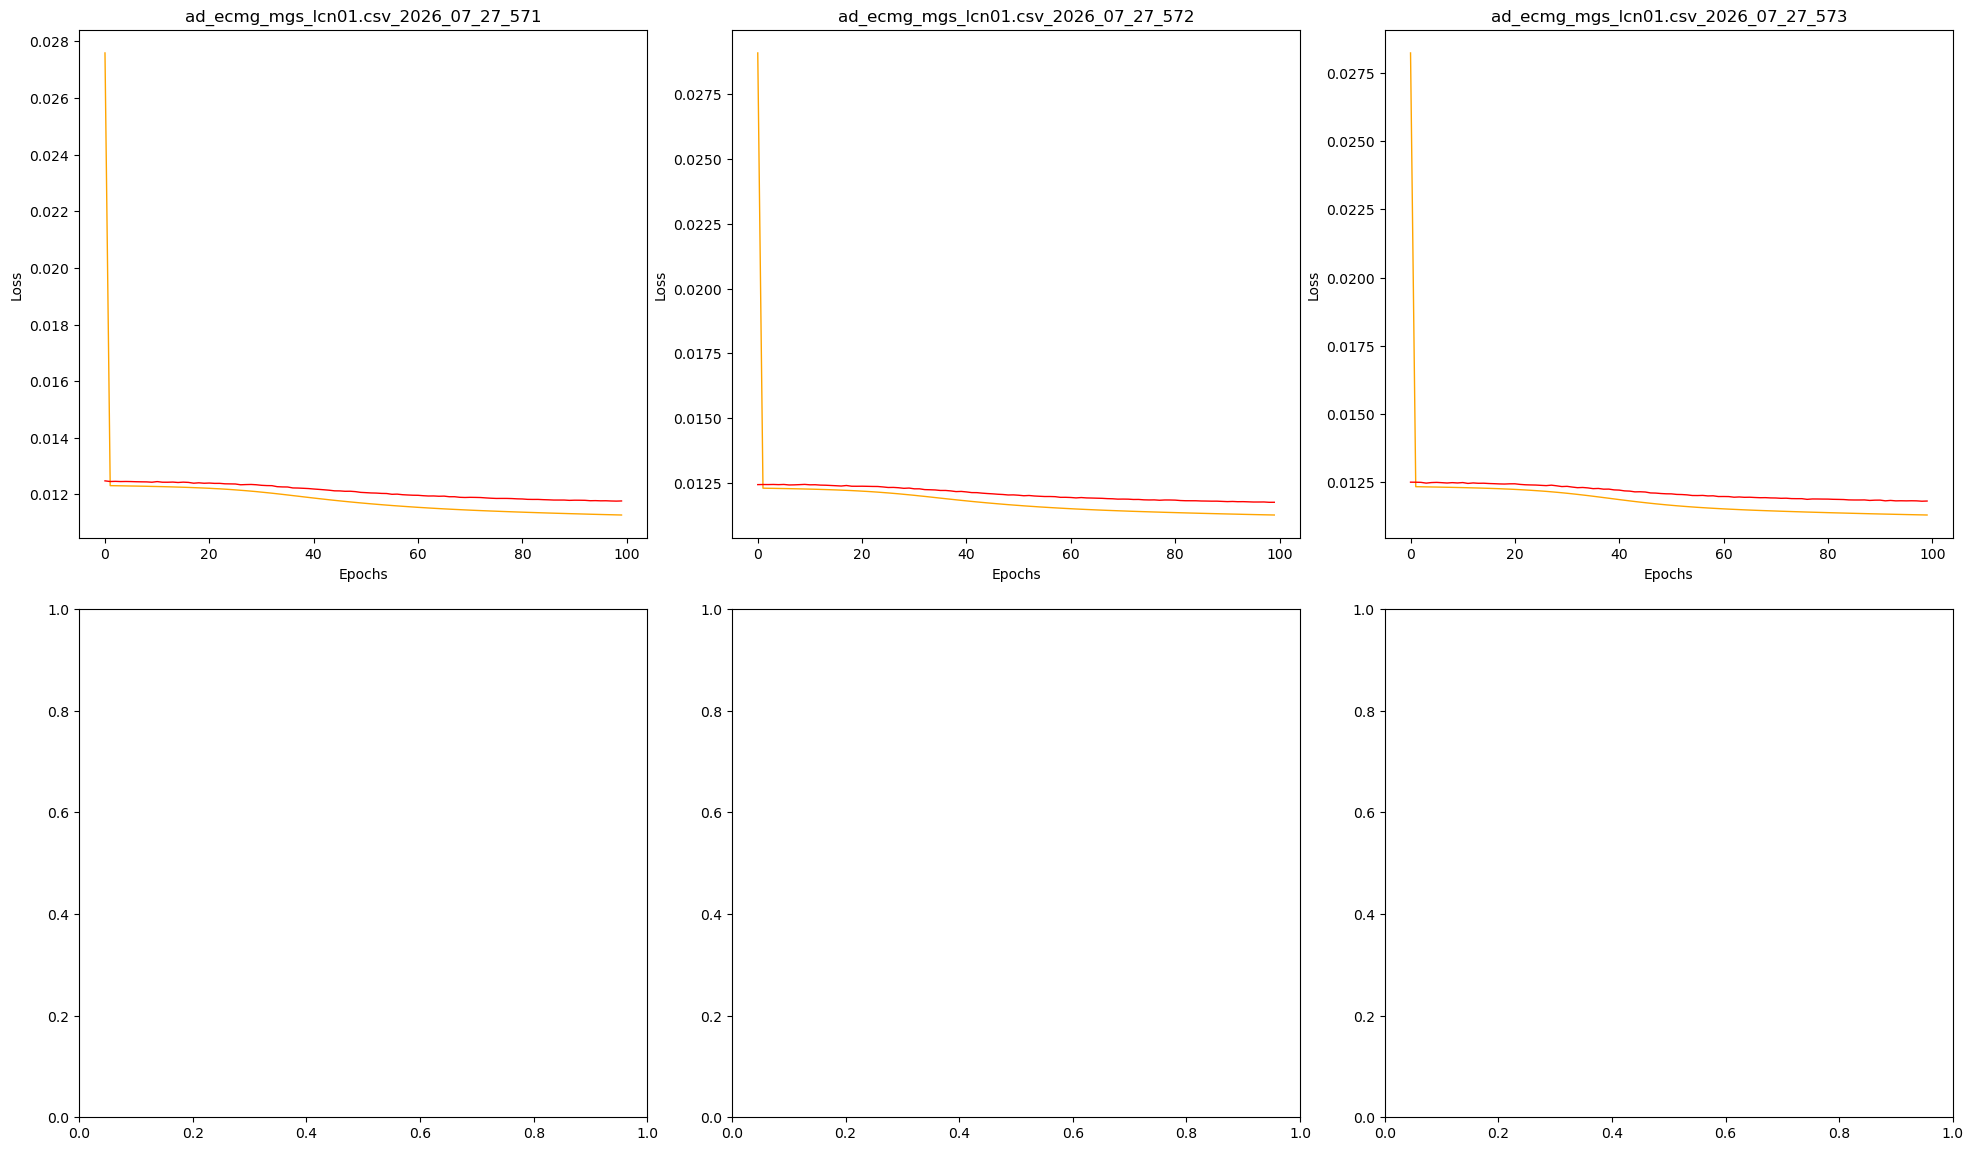

In [20]:
# set layout for panels of compendia and seeds
xd = len(comps) +1
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*10 ,yd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for comp in comps:
    xi=0
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1, 
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss, 
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1

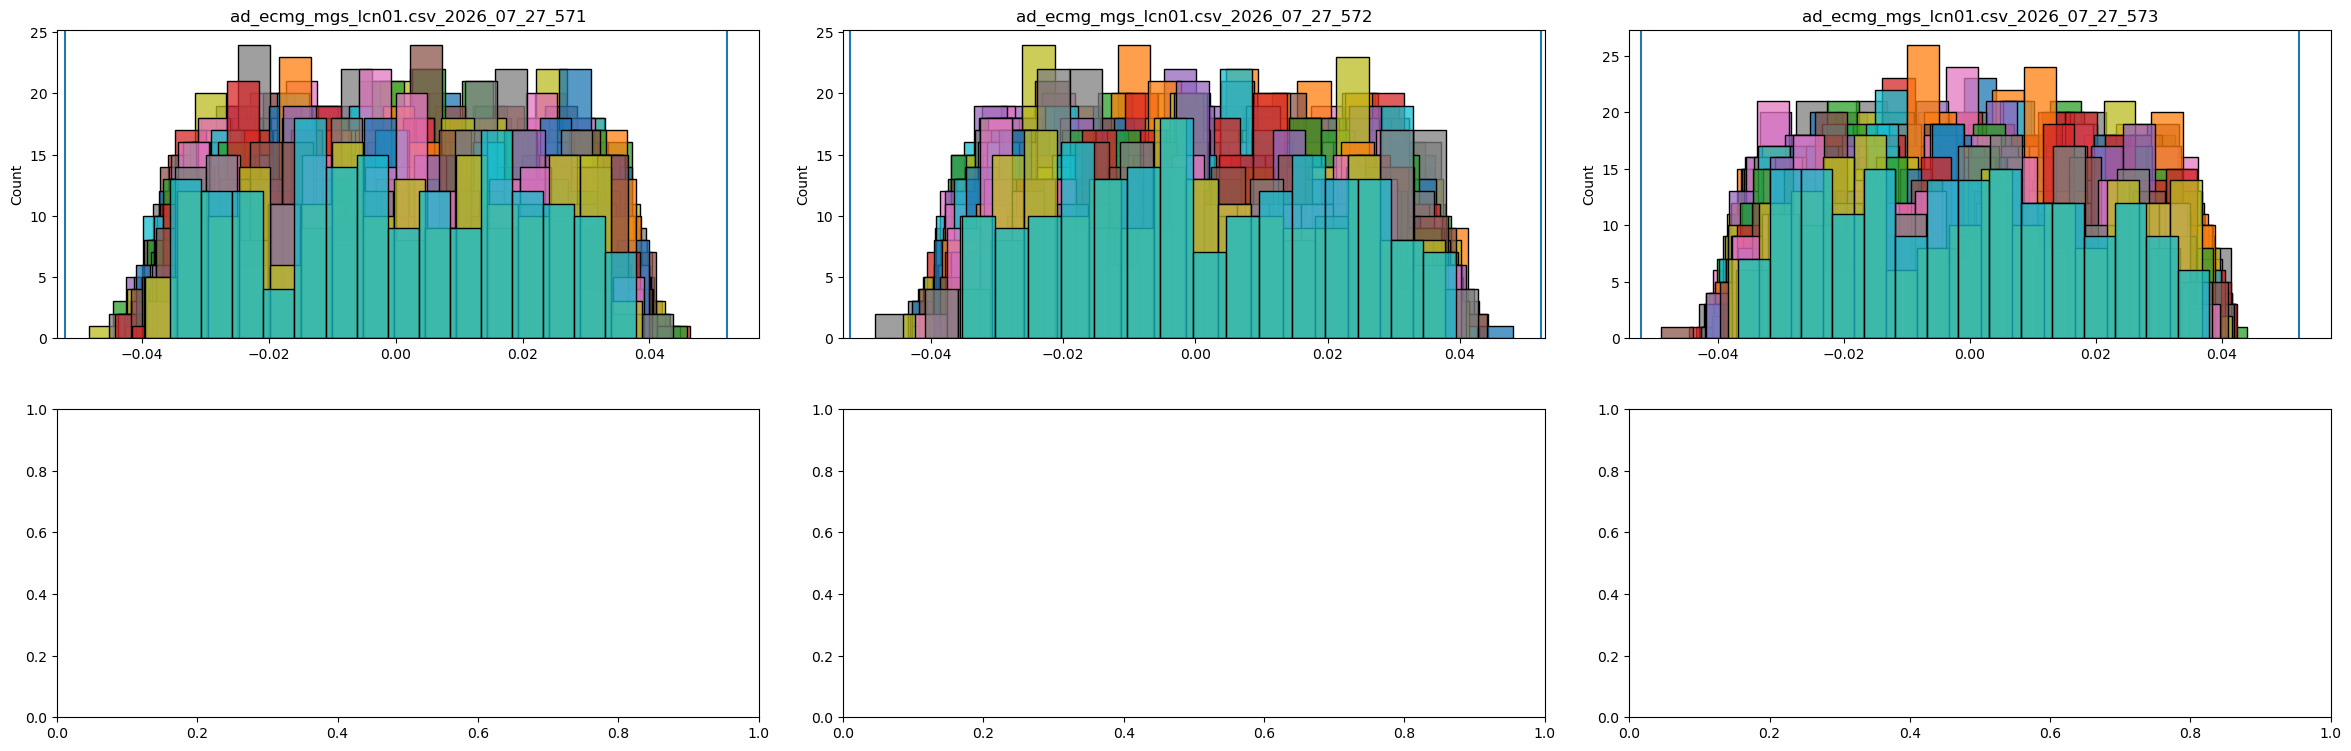

In [21]:
# set layout for panels of compendia and seeds
xd = len(comps) +1
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in comps:
        name = 'ad_' + comp[:-4] + '_2026_07_27_' + str(seed+571)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node], 
                ax=ax[xi,yi],
                binwidth = 0.005, 
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1

# KEGG